# mltu CRNN Training on Google Colab (GPU)

Trains the same CRNN+CTC as `train_mltu.py` but on Colab's T4 GPU with data staged to local SSD for ~10x I/O speedup.

Expected timing: ~30 min for 50 epochs on a T4 once data is local (vs ~11 h reading from Drive).

## Prerequisites
1. Upload `IAM_Words/` to Drive containing either `words.txt` + `words/` dir OR `words.txt` + `words.tgz` archive.
2. Set `DRIVE_DATA_DIR` / `DRIVE_OUT_DIR` in the **Parameters** cell.
3. Runtime → Change runtime type → **T4 GPU**.

After training, download `model.onnx` + `configs.yaml` from `DRIVE_OUT_DIR` into the local project's `models/mltu/`.

## 1. Setup

In [1]:
!pip install -q mltu==1.2.5 pyyaml tf2onnx onnx

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print(f'TensorFlow {tf.__version__}')
print(f'GPUs: {gpus}')
assert gpus, 'No GPU detected. Runtime → Change runtime type → T4 GPU.'

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 88.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 59.3 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 101.5 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 77.0 MB/s eta 0:00:00
TensorFlow 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Parameters

All tuning knobs in one place. Edit before running.

In [2]:
from pathlib import Path

# --- Paths on Drive ---
DRIVE_DATA_DIR = Path('/content/drive/MyDrive/IAM_Words')
DRIVE_OUT_DIR  = Path('/content/drive/MyDrive/models/mltu')

# --- Local staging (fast SSD) ---
LOCAL_DATA_DIR = Path('/content/IAM_Words_local')
LOCAL_OUT_DIR  = Path('/content/mltu_out')

# --- Model ---
HEIGHT = 32
WIDTH  = 256

# --- Training ---
BATCH_SIZE = 64
EPOCHS     = 50
LR         = 1e-3

print(f'Drive data: {DRIVE_DATA_DIR}')
print(f'Drive out:  {DRIVE_OUT_DIR}')
print(f'Local data: {LOCAL_DATA_DIR}')
print(f'Local out:  {LOCAL_OUT_DIR}')

Drive data: /content/drive/MyDrive/IAM_Words
Drive out:  /content/drive/MyDrive/models/mltu
Local data: /content/IAM_Words_local
Local out:  /content/mltu_out


## 3. Mount Drive & stage data locally

Copies the dataset from Drive to the Colab VM's local SSD on first run (~5 min). Every subsequent batch read goes from local disk, eliminating the Drive I/O bottleneck that made previous runs 17 s/step.

In [4]:
import shutil
import tarfile
from google.colab import drive

drive.mount('/content/drive')

assert (DRIVE_DATA_DIR / 'words.txt').exists(), f'words.txt missing in {DRIVE_DATA_DIR}'

LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)
LOCAL_OUT_DIR.mkdir(parents=True, exist_ok=True)
DRIVE_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Stage words.txt.
local_txt = LOCAL_DATA_DIR / 'words.txt'
if not local_txt.exists():
    shutil.copy(DRIVE_DATA_DIR / 'words.txt', local_txt)

# Stage PNGs: prefer extracting words.tgz directly to local SSD (fast) over
# copying already-extracted files from Drive (slow).
def count_pngs(root: Path) -> int:
    return sum(1 for _ in root.rglob('*.png'))

if count_pngs(LOCAL_DATA_DIR) == 0:
    drive_tgz = DRIVE_DATA_DIR / 'words.tgz'
    if drive_tgz.exists():
        print(f'Extracting {drive_tgz.name} to local SSD ...')
        with tarfile.open(str(drive_tgz), 'r:gz') as tar:
            first = tar.getnames()[0]
            # Archive may or may not have a top-level 'words/' dir.
            target = LOCAL_DATA_DIR if (first.startswith('words/') or first == 'words') else LOCAL_DATA_DIR / 'words'
            target.mkdir(parents=True, exist_ok=True)
            tar.extractall(path=str(target))
    else:
        print('No words.tgz; copying PNGs from Drive (this is slow) ...')
        for item in DRIVE_DATA_DIR.iterdir():
            if item.is_dir():
                shutil.copytree(item, LOCAL_DATA_DIR / item.name, dirs_exist_ok=True)

# Determine final WORDS_DIR: either LOCAL_DATA_DIR/words or LOCAL_DATA_DIR itself.
if (LOCAL_DATA_DIR / 'words').exists() and count_pngs(LOCAL_DATA_DIR / 'words') > 0:
    WORDS_DIR = LOCAL_DATA_DIR / 'words'
else:
    WORDS_DIR = LOCAL_DATA_DIR
WORDS_TXT = local_txt

print(f'WORDS_TXT: {WORDS_TXT}')
print(f'WORDS_DIR: {WORDS_DIR}')
print(f'PNGs:      {count_pngs(WORDS_DIR)}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting words.tgz to local SSD ...


/tmp/ipykernel_8667/1508297176.py:32: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=str(target))


WORDS_TXT: /content/IAM_Words_local/words.txt
WORDS_DIR: /content/IAM_Words_local/words
PNGs:      115320


## 4. Parse dataset

Builds `(path, label)` samples from `words.txt`, filtering entries marked `err` or with missing/empty images.

In [5]:
def load_samples(words_txt: Path, words_dir: Path):
    samples, vocab, max_len = [], set(), 0
    with open(words_txt, 'r', encoding='utf-8') as fh:
        for line in fh:
            if line.startswith('#') or not line.strip():
                continue
            parts = line.strip().split(' ')
            if len(parts) < 9 or parts[1] != 'ok':
                continue
            word_id, label = parts[0], ' '.join(parts[8:])
            a, b, *_ = word_id.split('-')
            img_path = words_dir / a / f'{a}-{b}' / f'{word_id}.png'
            if not img_path.exists() or img_path.stat().st_size == 0:
                continue
            samples.append([str(img_path), label])
            vocab.update(label)
            max_len = max(max_len, len(label))
    return samples, sorted(vocab), max_len

samples, vocab_list, max_word_length = load_samples(WORDS_TXT, WORDS_DIR)
vocab = ''.join(vocab_list)
assert samples, 'No samples loaded — check WORDS_DIR layout above.'
print(f'Samples: {len(samples)}')
print(f'Vocab size: {len(vocab_list)}')
print(f'Max word length: {max_word_length}')

Samples: 96454
Vocab size: 79
Max word length: 21


## 5. Sample visualization

Render 8 random samples to confirm the dataset loaded correctly before training.

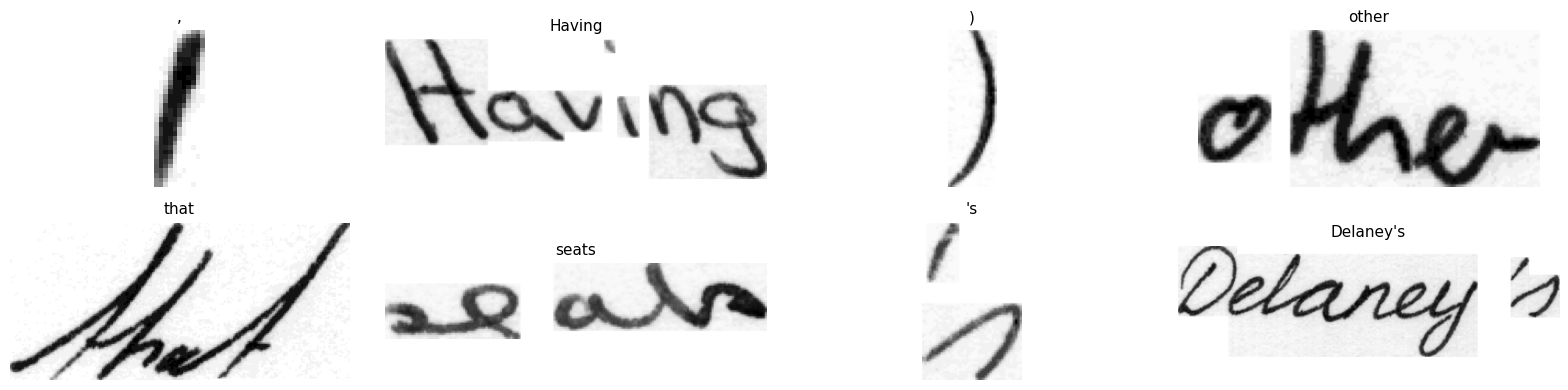

In [8]:
import random
import cv2
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 4))
for ax, (img_path, label) in zip(axes.flat, random.sample(samples, 8)):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap='gray')
    ax.set_title(label, fontsize=11)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 6. Write configs.yaml

In [9]:
import yaml

config = {
    'vocab': vocab,
    'height': HEIGHT,
    'width': WIDTH,
    'max_text_length': max_word_length,
}
with open(LOCAL_OUT_DIR / 'configs.yaml', 'w', encoding='utf-8') as fh:
    yaml.safe_dump(config, fh)
print(f'Wrote {LOCAL_OUT_DIR / "configs.yaml"}')

Wrote /content/mltu_out/configs.yaml


## 7. DataProvider + augmentation

Wraps mltu's DataProvider in a Keras `Sequence` since Colab's Keras 3 requires it. Augmentation applies to training batches only.

In [10]:
from tensorflow.keras.utils import Sequence
from mltu.annotations.images import CVImage
from mltu.augmentors import (
    RandomBrightness, RandomErodeDilate, RandomElasticTransform,
    RandomGaussianBlur, RandomRotate,
)
from mltu.dataProvider import DataProvider
from mltu.preprocessors import ImageReader
from mltu.transformers import ImageResizer, LabelIndexer, LabelPadding


class KerasSequenceProvider(Sequence):
    """Keras 3 requires fit() inputs to inherit from Sequence; mltu's DataProvider does not."""
    def __init__(self, provider):
        super().__init__()
        self.provider = provider
    def __len__(self):
        return len(self.provider)
    def __getitem__(self, index):
        return self.provider[index]
    def on_epoch_end(self):
        if hasattr(self.provider, 'on_epoch_end'):
            self.provider.on_epoch_end()


data_provider = DataProvider(
    dataset=samples,
    skip_validation=True,
    batch_size=BATCH_SIZE,
    data_preprocessors=[ImageReader(CVImage)],
    transformers=[
        ImageResizer(WIDTH, HEIGHT, keep_aspect_ratio=False),
        LabelIndexer(vocab),
        LabelPadding(max_word_length=max_word_length, padding_value=len(vocab)),
    ],
)

train_provider, val_provider = data_provider.split(split=0.9)

train_provider.augmentors = [
    RandomBrightness(random_chance=0.3, delta=100),
    RandomRotate(random_chance=0.3, angle=5),
    RandomErodeDilate(random_chance=0.3, kernel_size=(1, 1)),
    RandomGaussianBlur(random_chance=0.2, sigma=1.0),
    RandomElasticTransform(random_chance=0.2, alpha_range=(0, 0.05), sigma_range=(0.01, 0.02)),
]

train_seq = KerasSequenceProvider(train_provider)
val_seq   = KerasSequenceProvider(val_provider)
print(f'Train batches: {len(train_seq)}, Val batches: {len(val_seq)}')

INFO:DataProvider:Skipping Dataset validation...


Train batches: 1357, Val batches: 151


## 8. Model definition (CRNN + CNN dropout)

Residual-block CNN → width-major reshape → BiLSTM → softmax. Dropout layers between residual pairs reduce overfitting. Uses `Permute` and `Rescaling` for Keras 3 compatibility.

In [11]:
from tensorflow.keras.layers import (
    Activation, Add, BatchNormalization, Bidirectional,
    Conv2D, Dense, Dropout, Input, LSTM, Permute, Rescaling, Reshape,
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


def residual_block(x, filters, strides=1):
    shortcut = x
    x = Conv2D(filters, (3, 3), strides=strides, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(filters, (3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    if strides != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, (1, 1), strides=strides, padding='same', use_bias=False)(shortcut)
        shortcut = BatchNormalization()(shortcut)
    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    return x


def build_model(input_dim, output_dim):
    inputs = Input(shape=input_dim, name='input')
    x = Rescaling(1.0 / 255.0)(inputs)

    x = residual_block(x, 16)
    x = residual_block(x, 16)
    x = Dropout(0.1)(x)
    x = residual_block(x, 32, strides=2)
    x = residual_block(x, 32)
    x = Dropout(0.15)(x)
    x = residual_block(x, 64, strides=2)
    x = residual_block(x, 64)
    x = Dropout(0.2)(x)

    # (batch, H, W, C) → (batch, W, H, C) so width becomes the time axis.
    x = Permute((2, 1, 3))(x)
    shape = x.shape
    x = Reshape((shape[1], shape[2] * shape[3]))(x)

    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = Dropout(0.25)(x)

    x = Dense(output_dim + 1, activation='softmax', name='output')(x)
    return Model(inputs=inputs, outputs=x)


model = build_model(
    input_dim=(HEIGHT, WIDTH, 3),
    output_dim=len(vocab),
)
model.summary(line_length=110)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                   ┃ Output Shape              ┃          Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)             │ (None, 32, 256, 3)        │                0 │ -                          │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ rescaling (Rescaling)          │ (None, 32, 256, 3)        │                0 │ input[0][0]                │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ conv2d (Conv2D)                │ (None, 32, 256, 16)       │              432 │ rescaling[0][0]            │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ batch_normalization            │ (None, 32, 256, 16)       │               64 │ conv2d[0][0]               │
│ (BatchNormalization)           │                           │                  │                            │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ activation (Activation)        │ (None, 32, 256, 16)       │                0 │ batch_normalization[0][0]  │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)              │ (None, 32, 256, 16)       │            2,304 │ activation[0][0]           │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)              │ (None, 32, 256, 16)       │               48 │ rescaling[0][0]            │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ batch_normalization_1          │ (None, 32, 256, 16)       │               64 │ conv2d_1[0][0]             │
│ (BatchNormalization)           │                           │                  │                            │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ batch_normalization_2          │ (None, 32, 256, 16)       │               64 │ conv2d_2[0][0]             │
│ (BatchNormalization)           │                           │                  │                            │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ add (Add)                      │ (None, 32, 256, 16)       │                0 │ batch_normalization_1[0][… │
│                                │                           │                  │ batch_normalization_2[0][… │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ activation_1 (Activation)      │ (None, 32, 256, 16)       │                0 │ add[0][0]                  │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)              │ (None, 32, 256, 16)       │            2,304 │ activation_1[0][0]         │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ batch_normalization_3          │ (None, 32, 256, 16)       │               64 │ conv2d_3[0][0]             │
│ (BatchNormalization)           │                           │                  │                            │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ activation_2 (Activation)      │ (None, 32, 256, 16)       │                0 │ batch_normalization_3[0][… │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ co

 Total params: 850,416 (3.24 MB)

 Trainable params: 849,296 (3.24 MB)

 Non-trainable params: 1,120 (4.38 KB)

## 9. Compile & train

`CSVLogger` writes per-epoch metrics to a file so we can plot curves afterward. `ModelCheckpoint` keeps best-val-CER weights. `Model2onnx` auto-exports ONNX at training end.

In [12]:
from tensorflow.keras.callbacks import (
    CSVLogger, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard,
)
from mltu.tensorflow.callbacks import Model2onnx, TrainLogger
from mltu.tensorflow.losses import CTCloss
from mltu.tensorflow.metrics import CERMetric, WERMetric

LOG_CSV = LOCAL_OUT_DIR / 'training_log.csv'
H5_PATH = LOCAL_OUT_DIR / 'model.h5'

model.compile(
    optimizer=Adam(learning_rate=LR),
    loss=CTCloss(),
    metrics=[
        CERMetric(vocabulary=vocab),
        WERMetric(vocabulary=vocab),
    ],
)

callbacks = [
    EarlyStopping(monitor='val_CER', patience=10, verbose=1, mode='min'),
    ModelCheckpoint(filepath=str(H5_PATH), monitor='val_CER', mode='min', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_CER', factor=0.9, patience=5, verbose=1, mode='min'),
    CSVLogger(str(LOG_CSV), append=False),
    TensorBoard(log_dir=str(LOCAL_OUT_DIR / 'logs'), update_freq='epoch'),
    TrainLogger(str(LOCAL_OUT_DIR)),
    Model2onnx(saved_model_path=str(H5_PATH), metadata={'vocab': vocab}),
]

model.fit(
    train_seq,
    validation_data=val_seq,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/50
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - CER: 1.0218 - WER: 0.9695 - loss: 16.6932
Epoch 1: val_CER improved from None to 0.76297, saving model to /content/mltu_out/model.h5

Epoch 1: finished saving model to /content/mltu_out/model.h5
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 326s 226ms/step - CER: 0.7887 - WER: 0.9205 - loss: 12.1264 - val_CER: 0.7630 - val_WER: 0.9128 - val_loss: 8.6169 - learning_rate: 0.0010
Epoch 2/50
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - CER: 0.6630 - WER: 0.8673 - loss: 6.5863
Epoch 2: val_CER improved from 0.76297 to 0.57262, saving model to /content/mltu_out/model.h5

Epoch 2: finished saving model to /content/mltu_out/model.h5
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 299s 220ms/step - CER: 0.5817 - WER: 0.8214 - loss: 5.8212 - val_CER: 0.5726 - val_WER: 0.8188 - val_loss: 5.8018 - learning_rate: 0.0010
Epoch 3/50
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - CER: 0.5208 - WER: 0.7806 - loss: 4.2511
Epoch 3: val_CER improved from 0.57262 to 0.48587, sav

## 10. Training curves

Plot loss / CER / WER over epochs to inspect convergence and overfitting.

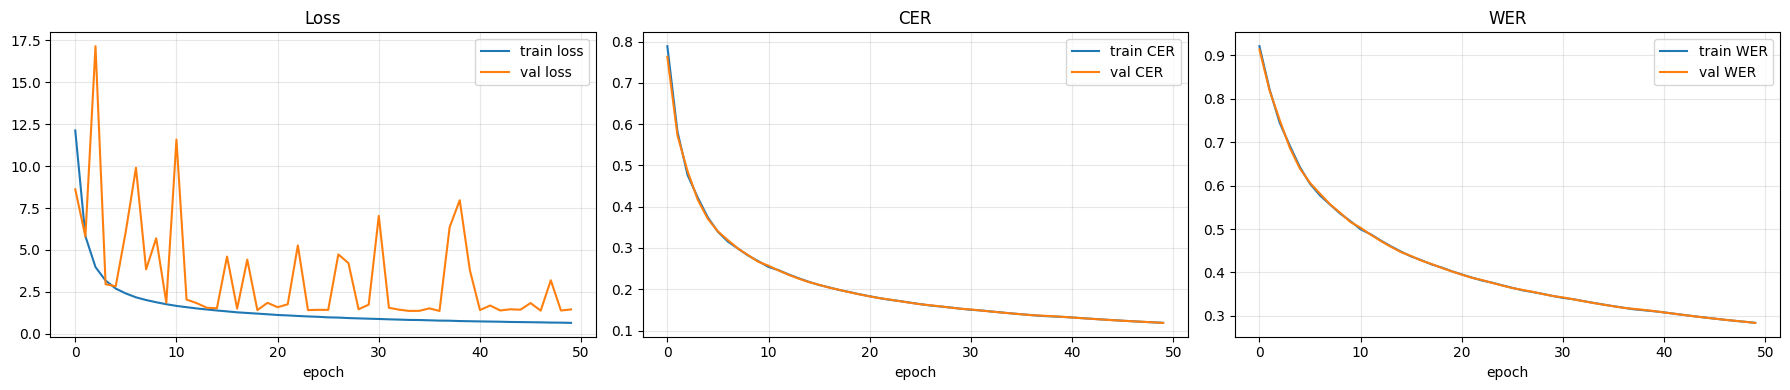

In [13]:
import pandas as pd

log = pd.read_csv(LOG_CSV)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (metric, title) in zip(axes, [('loss', 'Loss'), ('CER', 'CER'), ('WER', 'WER')]):
    if metric in log.columns:
        ax.plot(log['epoch'], log[metric], label=f'train {metric}')
    if f'val_{metric}' in log.columns:
        ax.plot(log['epoch'], log[f'val_{metric}'], label=f'val {metric}')
    ax.set_title(title)
    ax.set_xlabel('epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Export & verify

In [14]:
for f in ['model.onnx', 'configs.yaml', 'model.h5']:
    path = LOCAL_OUT_DIR / f
    status = f'{path.stat().st_size / 1e6:.1f} MB' if path.exists() else 'MISSING'
    print(f'  {f:20s}  {status}')

  model.onnx            3.4 MB
  configs.yaml          0.0 MB
  model.h5              10.4 MB


## 12. Copy to Drive

Moves artifacts from local SSD to Drive so you can download them. Place `model.onnx` + `configs.yaml` into your local `models/mltu/` then run `streamlit run app/streamlit_app.py`.

In [15]:
for f in ['model.onnx', 'configs.yaml', 'training_log.csv']:
    src = LOCAL_OUT_DIR / f
    if src.exists():
        shutil.copy(src, DRIVE_OUT_DIR / f)
        print(f'Copied {f} → {DRIVE_OUT_DIR / f}')
    else:
        print(f'Skipped {f} (not found)')

Copied model.onnx → /content/drive/MyDrive/models/mltu/model.onnx
Copied configs.yaml → /content/drive/MyDrive/models/mltu/configs.yaml
Copied training_log.csv → /content/drive/MyDrive/models/mltu/training_log.csv
